# CricFit AI — Yo-Yo Test Cadence Analysis Pipeline

**Purpose:** Prototype and validate the leg-cadence detection logic offline (on an uploaded test video) before porting it to the live webcam version in the FastAPI backend.

**Flow:**
1. Manual input — distance covered + time taken → basic average speed
2. Upload a test video (player running in place) → run MediaPipe Pose → extract ankle y-position over time
3. Peak detection on the ankle trajectory → compute cadence (steps/sec)
4. Combine manual input + cadence metrics → final JSON report (this is the object that gets sent to Groq later for tip generation)

This mirrors the same offline-first validation approach used in `batting_full_pipeline.ipynb` and `bowling_full_pipeline.ipynb` — prove the logic works on a known video before wiring it into anything live.

## 1. Install dependencies

In [2]:
!pip install -q mediapipe opencv-python-headless scipy numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 9.8 MB/s eta 0:00:00


## 2. Download the MediaPipe Pose Landmarker model (Tasks API)

Using `pose_landmarker_lite` — same model choice as the rest of the CricFit pipelines, for compatibility with the Tasks API (the legacy `mp.solutions` API was removed in recent MediaPipe builds).

In [3]:
!wget -q -O pose_landmarker_lite.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task
print('Model downloaded.')

Model downloaded.


## 3. Manual input — distance and time

Enter the Yo-Yo test result as reported: total distance covered (m) and total time taken (sec). This is the same input the frontend will collect from the user.

In [4]:
# --- EDIT THESE VALUES FOR TESTING ---
distance_m = 400.0   # total distance covered in the test, in meters
time_sec = 480.0     # total time taken, in seconds
yoyo_level = "16.3"  # optional: level.shuttle score if the player has it, else leave as None
target_board = "BCCI"       # which board's threshold to compare against (for the report)
target_yoyo_score = 17.1    # example current BCCI-style benchmark — update as needed, this varies by board and changes over time

avg_speed_mps = distance_m / time_sec if time_sec > 0 else 0.0
print(f"Average speed: {avg_speed_mps:.2f} m/s")

Average speed: 0.83 m/s


## 4. Upload the test video

Upload a short clip (~15-20s) of a player running in place. This stands in for what the live camera feed will capture in production.

In [5]:
from google.colab import files
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Using video: {video_path}")

Saving WIN_20260905_12_48_57_Pro.mp4 to WIN_20260905_12_48_57_Pro.mp4
Using video: WIN_20260905_12_48_57_Pro.mp4


## 5. Run MediaPipe Pose Landmarker frame-by-frame, extract ankle y-position

We track the average of left + right ankle y-coordinates per frame. As the player runs in place, this value oscillates up and down with each step — that oscillation is what we detect peaks/troughs on to compute cadence.

In [6]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# MediaPipe Pose landmark indices for ankles
LEFT_ANKLE = 27
RIGHT_ANKLE = 28

base_options = mp_python.BaseOptions(model_asset_path='pose_landmarker_lite.task')
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.VIDEO,
    num_poses=1,
)
landmarker = mp_vision.PoseLandmarker.create_from_options(options)

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_interval_ms = int(1000 / fps)

ankle_y_series = []
timestamps_ms = []
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    timestamp_ms = frame_idx * frame_interval_ms

    result = landmarker.detect_for_video(mp_image, timestamp_ms)

    if result.pose_landmarks:
        landmarks = result.pose_landmarks[0]
        left_ankle_y = landmarks[LEFT_ANKLE].y
        right_ankle_y = landmarks[RIGHT_ANKLE].y
        avg_ankle_y = (left_ankle_y + right_ankle_y) / 2.0
        ankle_y_series.append(avg_ankle_y)
        timestamps_ms.append(timestamp_ms)

    frame_idx += 1

cap.release()
landmarker.close()

ankle_y_series = np.array(ankle_y_series)
timestamps_sec = np.array(timestamps_ms) / 1000.0

print(f"Processed {frame_idx} frames, {len(ankle_y_series)} frames with a detected pose.")
print(f"Video duration: {timestamps_sec[-1]:.1f}s" if len(timestamps_sec) else "No pose detected.")

Processed 633 frames, 509 frames with a detected pose.
Video duration: 19.3s


## 6. Visualize the ankle trajectory (sanity check)

Before trusting the cadence number, look at the plot — you should see a clear, roughly periodic wave. If it's flat or noisy/random, the pose detection likely isn't tracking the player well (check lighting, framing, distance from camera) and the cadence result won't be reliable.

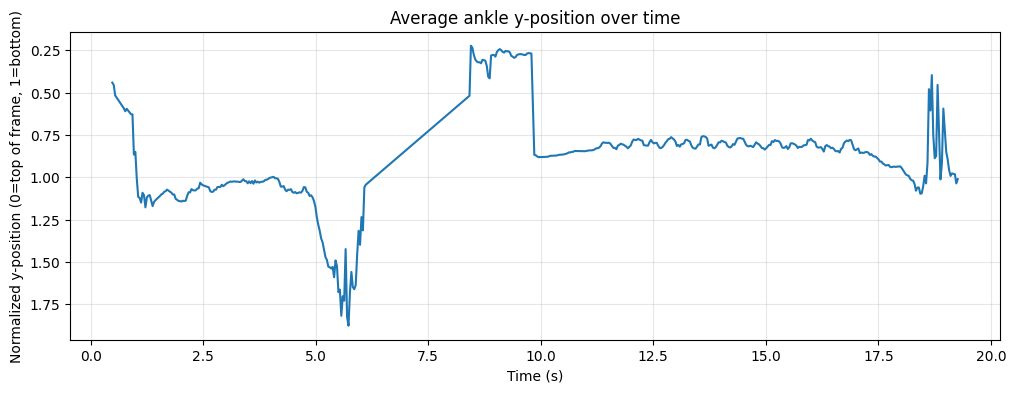

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(timestamps_sec, ankle_y_series)
plt.title('Average ankle y-position over time')
plt.xlabel('Time (s)')
plt.ylabel('Normalized y-position (0=top of frame, 1=bottom)')
plt.gca().invert_yaxis()  # so 'up' in the plot matches 'up' in real life
plt.grid(True, alpha=0.3)
plt.show()

## 7. Peak detection → cadence calculation

Each full up-down cycle of the ankle roughly corresponds to one step. We count peaks (or troughs — pick whichever is cleaner in your plot above) and divide by the duration to get steps/sec.

**Tune `distance` and `prominence` in `find_peaks` based on what you see in the plot** — these control how close together peaks can be and how pronounced a bump must be to count. Start with the defaults below and adjust if it over/under-counts compared to a manual count.

Steps detected: 33
Duration analyzed: 18.8s
Average cadence: 1.76 steps/sec
Cadence by third of test: [np.float64(1.96), np.float64(1.43), np.float64(2.03)]
Cadence trend: stable


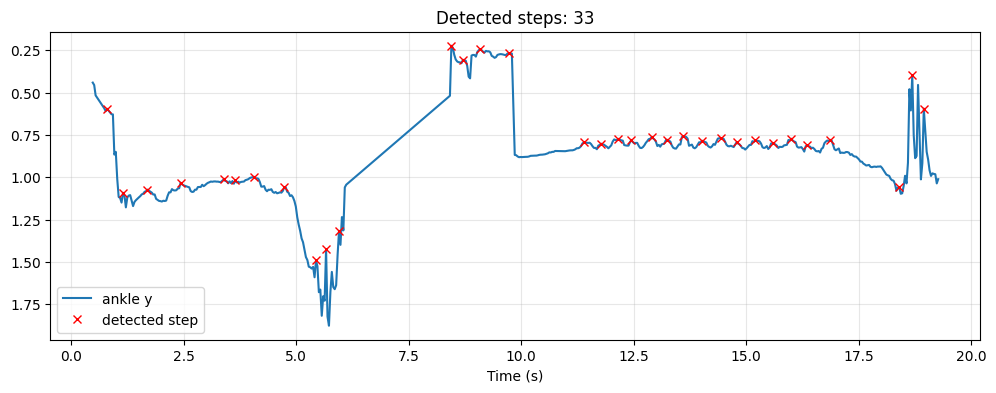

In [8]:
from scipy.signal import find_peaks

# invert so that 'foot lifted' (smaller y, since y grows downward) shows as a peak
inverted_series = -ankle_y_series

# min distance between peaks in frames — assume a step cycle won't be faster than ~0.25s
min_distance_frames = max(1, int(0.25 * fps))

peaks, properties = find_peaks(
    inverted_series,
    distance=min_distance_frames,
    prominence=0.01,   # tune this based on the plot above — increase if picking up noise
)

num_steps = len(peaks)
duration_sec = timestamps_sec[-1] - timestamps_sec[0] if len(timestamps_sec) > 1 else 1.0
avg_cadence = num_steps / duration_sec if duration_sec > 0 else 0.0

# rolling cadence trend: split the run into 3 equal windows and compute cadence in each,
# to see if the player's leg speed declines over the test (fatigue signal)
window_edges = np.linspace(0, len(ankle_y_series), 4).astype(int)
window_cadences = []
for i in range(3):
    start, end = window_edges[i], window_edges[i + 1]
    window_peaks = [p for p in peaks if start <= p < end]
    window_duration = (timestamps_sec[end - 1] - timestamps_sec[start]) if end > start else 1.0
    window_cadences.append(len(window_peaks) / window_duration if window_duration > 0 else 0.0)

cadence_trend = "stable"
if window_cadences[-1] < window_cadences[0] * 0.9:
    cadence_trend = "declining"
elif window_cadences[-1] > window_cadences[0] * 1.1:
    cadence_trend = "increasing"

print(f"Steps detected: {num_steps}")
print(f"Duration analyzed: {duration_sec:.1f}s")
print(f"Average cadence: {avg_cadence:.2f} steps/sec")
print(f"Cadence by third of test: {[round(c, 2) for c in window_cadences]}")
print(f"Cadence trend: {cadence_trend}")

# visualize detected peaks over the trajectory as a final sanity check
plt.figure(figsize=(12, 4))
plt.plot(timestamps_sec, ankle_y_series, label='ankle y')
plt.plot(timestamps_sec[peaks], ankle_y_series[peaks], 'rx', label='detected step')
plt.gca().invert_yaxis()
plt.title(f'Detected steps: {num_steps}')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Build the final JSON report

This is the exact structure to send to Groq for tip generation, and the contract the live backend version should also produce.

In [13]:
import json
from datetime import datetime, timezone

# --- deterministic comparison against the target, computed here (not left to Groq) ---
comparison = {
    "meets_target": None,
    "gap_to_target": None,
}
if target_yoyo_score is not None and yoyo_level is not None:
    try:
        current_numeric = float(yoyo_level)
        target_numeric = float(target_yoyo_score)
        comparison["meets_target"] = current_numeric >= target_numeric
        comparison["gap_to_target"] = round(target_numeric - current_numeric, 2)
    except (TypeError, ValueError):
        pass  # yoyo_level wasn't a clean number - leave comparison as None rather than guessing

report = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "manual_input": {
        "distance_m": distance_m,
        "time_sec": time_sec,
        "avg_speed_mps": round(avg_speed_mps, 2),
        "yoyo_level": yoyo_level,
    },
    "cadence_metrics": {
        "avg_steps_per_sec": round(avg_cadence, 2),
        "cadence_by_third": [round(c, 2) for c in window_cadences],
        "cadence_trend": cadence_trend,
        "analysis_duration_sec": round(duration_sec, 1),
    },
    "reference": {
        "target_board": target_board,
        "target_yoyo_score": target_yoyo_score,
    },
    "comparison": comparison,
}

print(json.dumps(report, indent=2))

with open('yoyo_report_sample.json', 'w') as f:
    json.dump(report, f, indent=2)
print("\nSaved to yoyo_report_sample.json")

{
  "generated_at": "2026-09-05T07:39:09.754302+00:00",
  "manual_input": {
    "distance_m": 400.0,
    "time_sec": 480.0,
    "avg_speed_mps": 0.83,
    "yoyo_level": "16.3"
  },
  "cadence_metrics": {
    "avg_steps_per_sec": 1.76,
    "cadence_by_third": [
      1.96,
      1.43,
      2.03
    ],
    "cadence_trend": "stable",
    "analysis_duration_sec": 18.8
  },
  "reference": {
    "target_board": "BCCI",
    "target_yoyo_score": 17.1
  },
  "comparison": {
    "meets_target": false,
    "gap_to_target": 0.8
  }
}

Saved to yoyo_report_sample.json


## 9. Generate an annotated demo video (skeleton overlay + live stats box)

Re-runs pose detection over the video and draws:
- the MediaPipe skeleton on the player
- a stats box (current step count, live cadence, elapsed time) in the corner of the frame

Useful for showing judges/teammates the pipeline actually working, without them having to read a JSON file. The raw OpenCV output isn't always playable outside a browser/Colab, so the final cell re-encodes it with `ffmpeg` (H.264 + AAC-safe container) so it opens correctly and can be shared directly over WhatsApp.

In [11]:
# mediapipe.solutions (legacy drawing_utils) is deprecated/removed in newer mediapipe builds,
# same issue as the mp.solutions -> Tasks API migration done for the main pipeline.
# So we draw the skeleton manually with plain OpenCV instead of relying on mp_drawing.

# Standard 33-point MediaPipe Pose connections (index pairs), hardcoded since
# mp_solutions.pose.POSE_CONNECTIONS is no longer importable.
POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20),
    (11, 23), (12, 24), (23, 24), (23, 25), (25, 27), (27, 29), (29, 31), (27, 31),
    (24, 26), (26, 28), (28, 30), (30, 32), (28, 32),
]

def draw_pose_landmarks(frame, landmarks, w, h):
    """Draw skeleton connections + joint dots directly with OpenCV."""
    points = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks]
    for a, b in POSE_CONNECTIONS:
        if a < len(points) and b < len(points):
            cv2.line(frame, points[a], points[b], (0, 200, 255), 2)
    for x, y in points:
        cv2.circle(frame, (x, y), 4, (0, 255, 0), -1)
    return frame

cap = cv2.VideoCapture(video_path)
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

raw_output_path = 'yoyo_annotated_raw.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(raw_output_path, fourcc, fps, (frame_w, frame_h))

# re-open a fresh landmarker instance (the one from section 5 was closed)
landmarker2 = mp_vision.PoseLandmarker.create_from_options(
    mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path='pose_landmarker_lite.task'),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_poses=1,
    )
)

steps_so_far = 0
peak_set = set(peaks.tolist())
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    timestamp_ms = frame_idx * frame_interval_ms
    result = landmarker2.detect_for_video(mp_image, timestamp_ms)

    if result.pose_landmarks:
        landmarks = result.pose_landmarks[0]
        frame = draw_pose_landmarks(frame, landmarks, frame_w, frame_h)

    if frame_idx in peak_set:
        steps_so_far += 1

    elapsed_sec = timestamp_ms / 1000.0
    live_cadence = steps_so_far / elapsed_sec if elapsed_sec > 0 else 0.0

    # stats box (top-left corner)
    box_w, box_h = 260, 100
    overlay = frame.copy()
    cv2.rectangle(overlay, (10, 10), (10 + box_w, 10 + box_h), (0, 0, 0), -1)
    frame = cv2.addWeighted(overlay, 0.55, frame, 0.45, 0)
    cv2.putText(frame, f"Steps: {steps_so_far}", (22, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Cadence: {live_cadence:.2f}/s", (22, 68), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Time: {elapsed_sec:.1f}s", (22, 96), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    writer.write(frame)
    frame_idx += 1

cap.release()
writer.release()
landmarker2.close()
print(f"Raw annotated video written to {raw_output_path}")

Raw annotated video written to yoyo_annotated_raw.mp4


### Re-encode for WhatsApp compatibility

OpenCV's `mp4v` output often won't preview/play correctly on WhatsApp or some phones. Re-encoding with `ffmpeg` to H.264 video + AAC audio in a standard MP4 container fixes that. This also keeps the file reasonably small — WhatsApp compresses/limits shared video anyway, so there's no benefit to a large/high-bitrate export.

In [12]:
final_output_path = 'yoyo_demo_whatsapp.mp4'

!ffmpeg -y -i {raw_output_path} -c:v libx264 -profile:v baseline -level 3.0 -pix_fmt yuv420p -movflags +faststart -crf 26 -preset veryfast -an {final_output_path}

import os
size_mb = os.path.getsize(final_output_path) / (1024 * 1024)
print(f"\nFinal WhatsApp-ready video: {final_output_path} ({size_mb:.1f} MB)")

from google.colab import files
files.download(final_output_path)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps

1. Check the plots above — confirm the detected steps line up with what you'd count by eye in the video.
2. Tune `prominence` / `distance` in the `find_peaks` call if the count looks off.
3. Once this is reliable, port the logic in cells 5–8 into a plain Python module (`cadence_tracker.py`) that processes a rolling buffer of frames instead of a full pre-loaded video — that becomes the function the FastAPI WebSocket handler calls for the live webcam version.
4. Send the JSON from step 8 to Groq with a prompt asking for specific cadence/speed improvement tips referencing these exact numbers.